In [1]:
from relaqs.save_results import SaveResults
from relaqs.plot_data import *
from relaqs.api import gates
from relaqs.api.utils import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

/Users/vishchaudhary/rl-repo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-06-22 23:41:59,712	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-06-22 23:41:59,870	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-06-22 23:42:03,878	WARNING __init__.py:10 -- DDPG has/have been moved to `rllib_contrib` and will no longer be maintained by the RLlib team. You can still use it/them normally inside RLlib util Ray 2.8, but from Ray 2.9 on, all `rllib_contrib` algorithms will no longer be part of the core repo, and will therefore have to be installed separately with pinned dependencies for e.g. ray[rl

In [26]:
def training_figure(save_dir,
                    figure_title='',
                    plot_filename='plot',
                    perform_analysis=False,
                    save_plot=False):
    """Plot 1–F (log scale) and reward on shared x-axis with dual y-axes."""
    # ---------------------- Load data --------------------------------------
    df = pd.read_csv(os.path.join(save_dir, "env_data.csv"), header=0)
    fidelities   = df.iloc[:, 0].values
    rewards      = df.iloc[:, 1].values
    episode_ids  = df.iloc[:, -1].values

    if perform_analysis:
        perform_action_analysis(df=df)

    print("max fidelity:", fidelities.max())
    print("max reward:  ", rewards.max())

    # --------> Final per-episode values -----------------------------------
    final_fidelity_per_episode  = []
    final_infelity_per_episode  = []
    sum_of_rewards_per_episode  = []

    current_ep   = episode_ids[0]
    current_fid  = fidelities[0]
    current_sum  = rewards[0]
    n_steps      = len(episode_ids)
    for i in range(1, n_steps):
        if episode_ids[i] != current_ep:
            final_fidelity_per_episode.append(current_fid)
            final_infelity_per_episode.append(1 - current_fid)
            sum_of_rewards_per_episode.append(current_sum)
            current_sum = 0
        current_ep  = episode_ids[i]
        current_fid = fidelities[i]
        current_sum += rewards[i]
    # handle last episode
    final_fidelity_per_episode.append(current_fid)
    final_infelity_per_episode.append(1 - current_fid)
    sum_of_rewards_per_episode.append(current_sum)

    # ---------------------- Rolling averages --------------------------------
    window = 100
    def rolling_avg(x):
        return np.array([
            x[max(0, i - window): i + 1].mean()
            for i in range(len(x))
        ])

    avg_inf = rolling_avg(np.array(final_infelity_per_episode))
    avg_rw  = rolling_avg(np.array(sum_of_rewards_per_episode))

    # Round to avoid floating noise
    avg_inf = np.round(avg_inf, 6)
    avg_rw  = np.round(avg_rw, 6)

    # Print last-100 stats if available
    if len(avg_inf) >= window:
        print("Avg infidelity over last 100 eps:", avg_inf[-window:].mean())
    if len(avg_rw) >= window:
        print("Avg reward     over last 100 eps:", avg_rw[-window:].mean())

    # ------------------------------ Plotting -------------------------------
    episodes = np.arange(len(final_infelity_per_episode))
    step     = 5  # plot every 5th raw point

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2      = ax1.twinx()

    # raw + avg infidelity
    ax1.scatter(episodes[::step],
                final_infelity_per_episode[::step],
                s=5, alpha=0.3,
                label='Infidelity (raw)',
                color='tab:red')
    ax1.plot(episodes,
             avg_inf,
             color='k', linewidth=1.5,
             label='Moving Avg (100 episode window)')
    ax1.set_yscale('log')
    ax1.set_ylabel('1 - Fidelity', color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_xlabel('Episodes')

    # raw + avg reward
    ax2.scatter(episodes[::step],
                sum_of_rewards_per_episode[::step],
                s=5, alpha=0.3,
                label='Reward (raw)',
                color='tab:blue')
    ax2.plot(episodes,
             avg_rw,
             color='k', linewidth=1.5,
             )
    ax2.set_ylabel('Sum of Rewards', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    # title + combined legend outside
    plt.title(figure_title)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2,
               labels1 + labels2,
               bbox_to_anchor=(1.15, 1),
               loc='upper left',
               fontsize=10)

    plt.tight_layout()

    if save_plot:
        fig.savefig(os.path.join(save_dir, plot_filename),
                    bbox_inches='tight',
                    pad_inches=0.1)
        plt.close(fig)
    else:
        plt.show()

max fidelity: 0.9999996938560252
max reward:   21.540320896665445
Avg infidelity over last 100 eps: 0.00858041
Avg reward     over last 100 eps: 13.03178578


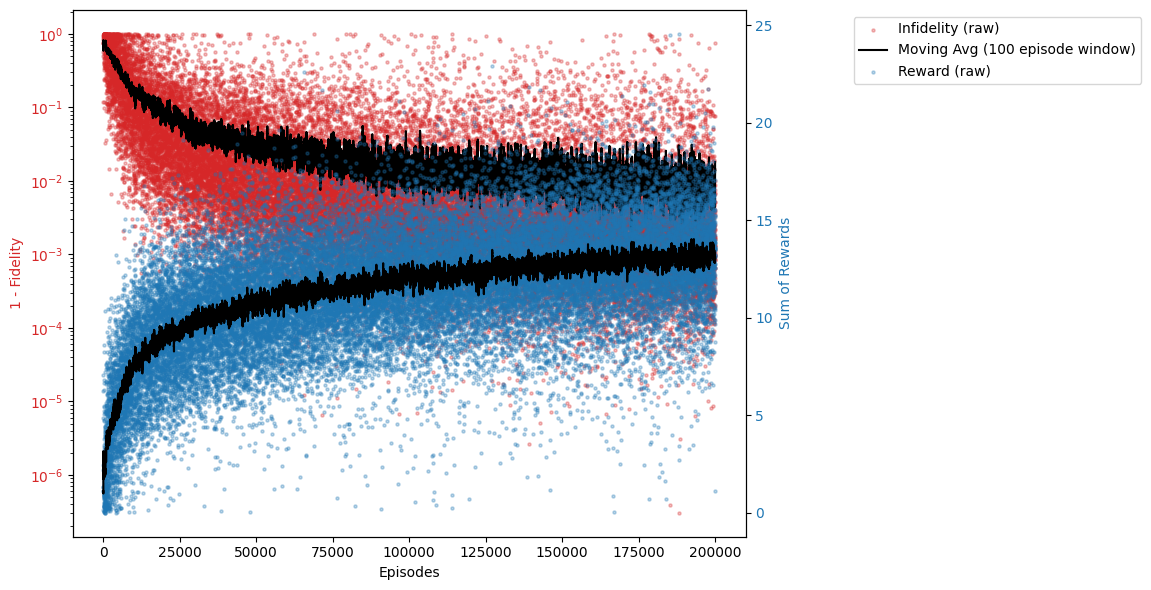

In [27]:
training_figure('/Users/vishchaudhary/rl-repo/results/2025-03-26_03-13-38/', save_plot=False, plot_filename='figure_A_.png')

In [46]:

def plot_infidelity_distribution_by_noise(run_dirs,
                             noise_params,
                             window=100,
                             save_plot=False,
                             out_filename='all_runs_infidelity.png'):
    """
    Overlaid infidelity‐vs‐episode rolling‐average curves for multiple runs.

    run_dirs     : list of str
        Directories containing 'env_data.csv'.
    noise_params : list of (low_relax, high_relax, detuning_std)
    window       : int
        Rolling‐average window size in episodes.
    save_plot    : bool
    out_filename : str
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    cmap   = plt.get_cmap('tab10')

    def noise_strength(low, high, det_std):
        σ_relax  = (high - low) / np.sqrt(12)
        σ_detune = det_std
        return np.sqrt(σ_relax**2 + σ_detune**2)

    def rolling_avg(x, w):
        return np.array([x[max(0, i-w):i+1].mean() for i in range(len(x))])

    for idx, (rd, (low, high, det_std)) in enumerate(zip(run_dirs, noise_params)):
        # --- load data ---
        df          = pd.read_csv(os.path.join(rd, 'env_data.csv'), header=0)
        fidelities  = df.iloc[:, 0].values
        episode_ids = df.iloc[:, -1].values

        # --- extract final fidelity per episode ---
        final_inf = []
        ep = episode_ids[0]
        fid = fidelities[0]
        for i in range(1, len(episode_ids)):
            if episode_ids[i] != ep:
                final_inf.append(1 - fid)
                ep = episode_ids[i]
            fid = fidelities[i]
        final_inf.append(1 - fid)
        final_inf = np.array(final_inf)

        # --- rolling average ---
        avg_inf = rolling_avg(final_inf, window)

        # --- plot ---
        ns = noise_strength(low, high, det_std)
        ax.plot(avg_inf,
                color=cmap(idx),
                alpha=0.7,
                linewidth=2,
                label=f'σ={ns:.2e}')

    ax.set_yscale('log')
    ax.set_xlabel('Episodes')
    ax.set_ylabel('1 – Fidelity (rolling avg)')
    ax.set_title('Noise Unaware: Infidelity vs Episodes')
    ax.grid(True, which='both', ls=':')
    ax.legend(title='Noise strength', loc='best', fontsize=9)

    plt.tight_layout()
    if save_plot:
        fig.savefig(out_filename, bbox_inches='tight', pad_inches=0.1)
        plt.close(fig)
    else:
        plt.show()

In [47]:
noise_aware_filepaths = ['/Users/vishchaudhary/rl-repo/results/2025-06-21_13-11-26/',
                         '/Users/vishchaudhary/rl-repo/results/2025-06-21_16-10-05/',
                         '/Users/vishchaudhary/rl-repo/results/2025-06-21_17-15-50/',
                         '/Users/vishchaudhary/rl-repo/results/2025-06-21_18-33-46/',
                         '/Users/vishchaudhary/rl-repo/results/2025-06-21_20-46-17/']
noise_aware_parameters = [(4e-05,0.0002,10000),
                          (4e-06,0.002,100000),
                          (4e-07,0.02,1000000),
                          (4e-08,0.2,10000000),
                          (4e-09,2.0,100000000)]

noise_unaware_filepaths = ['/Users/vishchaudhary/rl-repo/results/2025-06-21_22-53-15/',
                           '/Users/vishchaudhary/rl-repo/results/2025-06-22_13-40-20/',
                           '/Users/vishchaudhary/rl-repo/results/2025-06-22_15-19-06/',
                           '/Users/vishchaudhary/rl-repo/results/2025-06-22_16-56-50/',
                           '/Users/vishchaudhary/rl-repo/results/2025-06-22_18-04-43/']
noise_unaware_parameters = [(4e-05,0.0002,10000),
                          (4e-06,0.002,100000),
                          (4e-07,0.02,1000000),
                          (4e-08,0.2,10000000),
                          (4e-09,2.0,100000000)]

# plot_infidelity_distribution_by_noise(noise_aware_filepaths, noise_aware_parameters, save_plot=True, out_filename='noise_aware.png')

plot_infidelity_distribution_by_noise(noise_unaware_filepaths, noise_unaware_parameters, save_plot=True, out_filename='noise_unaware.png')